# Chapitre 3 : Résolution d'un problème à plusieurs barres 

## Installation des modules

- pip install --user https://c4science.ch/diffusion/3683/slides.git


In [1]:
import sys
sys.path.append('/Users/metralmathilde/Library/Python/3.7/lib/python/site-packages')

import numpy as np
from plot import *

## À lire avant de commencer

- L'indexation sur Python commence à 0 (et non à 1 contrairement à Matlab). C'est pourquoi, nous fixerons nos premiers paramètres (nœud, élément, ligne et colonne des matrices, etc) avec la valeur 0.

- La fonction "plot_matrix(matrix, matrix_name)" permet de visualiser les matrices. Elle prend en entrée:
        - matrix : le nom de la variable
        
        - matrix_name = 'nom_matrix'. Par exemple, matrix_name prendra les valeurs de 'C' si on veut la matrice de connectivité.
        
- Le Notebook se décompose en 4 chapitres :
        1. Matrice de connectivité
        2. Matrice de numérotation d'équation
        3. Matrice de raideur
        4. Un exemple complet

## 1. Matrice de connectivité

Dans cette section, nous tâcherons de comprendre les différentes variables influençant la matrice de connectivité. On considère la structure suivante comme référence. On définit la matrice des positions et de connectivité comme suit :

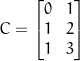

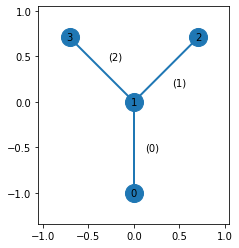

In [2]:
positions = [
    [0, -1],
    [0, 0],
    np.array([1, 1])/np.sqrt(2),
    np.array([-1, 1])/np.sqrt(2)
]

conn = [
    [0, 1],
    [1, 2],
    [1, 3]
]
plot_matrix(conn, 'C')

plot_structure(positions, conn)

### 1.1.  Influence de la numérotation des éléments. 

- Inverser les lignes de la matrice de connectivité. La position des nœuds ne change pas.

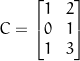

In [3]:
conn = [
    [1, 2],
    [0, 1],
    [1, 3]
]

plot_matrix(conn, 'C')

positions = [
    [0, -1],
    [0, 0],
    np.array([1, 1])/np.sqrt(2),
    np.array([-1, 1])/np.sqrt(2)
]

#### Question:

Quel impact y a-t-il lorsque nous inversons les lignes de la matrice de connectivité sur la structure?

#### Réponse: 

_Saisir votre réponse ici_


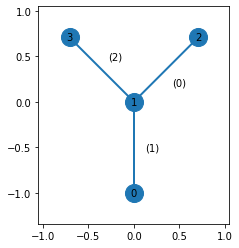

In [4]:
plot_structure(positions, conn)

### 1.2. Influence de la position des nœuds. 

- Permuter les nœuds 1 et 3 dans la matrice "positions"

In [5]:
positions = [
    [0, -1],
    np.array([-1, 1])/np.sqrt(2),
    np.array([1, 1])/np.sqrt(2),
    [0, 0]
]

- Écriver la matrice de connectivité associée à ce changement

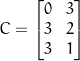

In [6]:
conn = [
    [0, 3],
    [3, 2],
    [3, 1]
]

plot_matrix(conn, 'C')

- Vérifier sur la figure ci-dessous que les nœuds 1 et 3 ont bien permuté

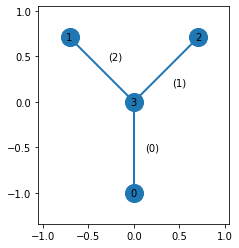

In [7]:
plot_structure(positions, conn)

#### Question:

Quel impact y a-t-il lorsque l'on permutte les nœuds sur la matrice de connectivité?

#### Réponse:

_Saisir votre réponse ici_


### 1.3. Influence des matrices positions et de connectivité sur la structure

- Dessiner sur papier la structure obtenue si nous définissons la matrice C et la position des nœuds comme suit :

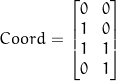

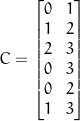

In [8]:
positions = [
    [0, 0],
    [1, 0],
    [1, 1],
    [0, 1]
]
plot_matrix(positions, 'Coord')


conn = [
    [0, 1],
    [1, 2],
    [2, 3],
    [0, 3],
    [0, 2],
    [1, 3],
]

plot_matrix(conn, 'C')

#### Réponse:

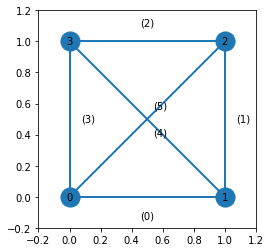

In [9]:
plot_structure(positions, conn)

## 2. La matrice de numérotation d'équation

Dans cette section, nous tâcherons de comprendre les différentes variables influençant la matrice de numérotation d'équation par élément. 

- Reprenons notre structure de référence. On ajoute maintenant les indices des ddl \[i; j\] pour chaque nœud.

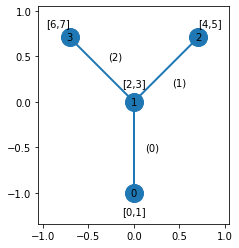

In [10]:
positions = [
    [0, -1],
    [0, 0],
    np.array([1, 1])/np.sqrt(2),
    np.array([-1, 1])/np.sqrt(2)
]

conn = [
    [0, 1],
    [1, 2],
    [1, 3]
]

# La variable plot_eqn = 'packed' sert simplement à ajouter les ddl sur le plot. La variable ret nous sera utile
# pour sortir la matrice Eqn associée.

ret = plot_structure(positions, conn,plot_eqn='packed')

### 2.1. Définition de la matrice de numérotation par nœud Eqn

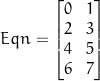

In [11]:
plot_matrix(ret['eqn_node'], 'Eqn')

#### Question:

Que représente cette matrice ? Définir à quoi correspondent les lignes et les colonnes.

#### Réponse:

_Saisir votre réponse ici_

### 2.2. Définition de la matrice de numérotation par élément Eqe

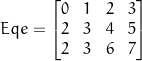

In [12]:
plot_matrix(ret['eqn_elem'], 'Eqe')

#### Question:

Que représente cette matrice ? Définir à quoi correspondent les lignes et les colonnes afin de bien comprendre la différence entre Eqn et Eqe.

#### Réponse:

_Saisir votre réponse ici_

### 2.3. Influence de la définition des ddl associés à chacun des nœuds.

- Inverser la ligne (0) et la ligne (1) de la matrice eqn_node

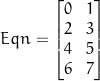

In [13]:
eqn_node = np.array(
    [[2, 3],
     [0, 1],
     [4, 5],
     [6, 7]]
)

plot_matrix(ret['eqn_node'], 'Eqn')

- Visualiser la structure avec la nouvelle matrice Eqn définie précédemment

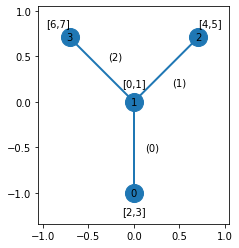

In [14]:
ret = plot_structure(positions, conn, plot_eqn=eqn_node)

#### Question:

Quel impact cela aura-t-il sur la matrice de numéro d'équation par éléments ?

#### Réponse:

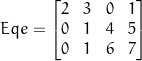

In [15]:
plot_matrix(ret['eqn_elem'], 'Eqe')

### 2.4. Influence de la position des nœuds

- Permuter les nœuds 1 et 2 dans la matrice "positions"

In [16]:
positions = [
    [0, -1],
    np.array([1, 1])/np.sqrt(2),
    [0, 0],
    np.array([-1, 1])/np.sqrt(2)
]

- Modifier la matrice de connectivité associée à ce changement

In [17]:
conn = [
    [0, 2],
    [2, 1],
    [2, 3]
]

- Vérifier sur la figure ci-dessous que les nœuds 1 et 2 ont bien permuté

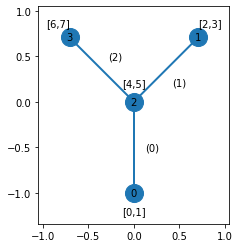

In [18]:
ret = plot_structure(positions, conn, plot_eqn="packed")

#### Question:

Quel impact cela aura-t-il sur la matrice de numérotation d'équation par élément Eqe?

#### Réponse:

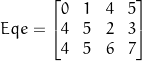

In [19]:
plot_matrix(ret['eqn_elem'], 'Eqe')

### 2.5. Sur la base de l'exemple 1.3. , comment définiriez vous les matrices Eqn et Eqe?

- Rappel des matrices de connectivité et de positions

In [20]:
positions = [
    [0, 0],
    [1, 0],
    [1, 1],
    [0, 1]
]

conn = [
    [0, 1],
    [1, 2],
    [2, 3],
    [0, 3],
    [0, 2],
    [1, 3],
]

#### Réponse:

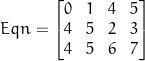

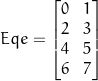

In [21]:
plot_matrix(ret['eqn_elem'], 'Eqn')
plot_matrix(ret['eqn_node'], 'Eqe')

### 2.6. Influence du regroupement les ddl

Reprenons notre structure de référence. Dans cette partie, nous changeons la façon de grouper les ddls; nous choissisons de ne plus les grouper par nœud, c'est-à-dire (d1x, d1y, d2x, d2y) mais par variable (d1x, d2x, d1y, d2y). 

#### Question:

- Comment s'écrirait la matrice Eqe? 

- Quel serait l'influence de ce changement sur la matrice de raideur K? 

- En quoi un tel changement serait utile?

#### Réponse:

_Saisir votre réponse ici_

## 3. Matrice de raideur

Afin de traiter cette partie dans le cas le plus général, nous utiliserons une écriture symbolique. Pour cela, nous utilisons la fonction _Symbol_ qui prend en entrée le nom de la variable, le type de varible (réelle, positive, etc).


Puis nous pourrons affecter des valeurs à l'aide de la fonction _subs_. 

### 3.1. Barre inclinée

Nous nous intéressons à la matrice de raideur dans le cas d'une barre tounée, c'est-à-dire que nous étudirons ses composantes en fonctions de l'angle de rotation de la barre. Un schéma s'affiche en lançant la cellule ci-dessous :

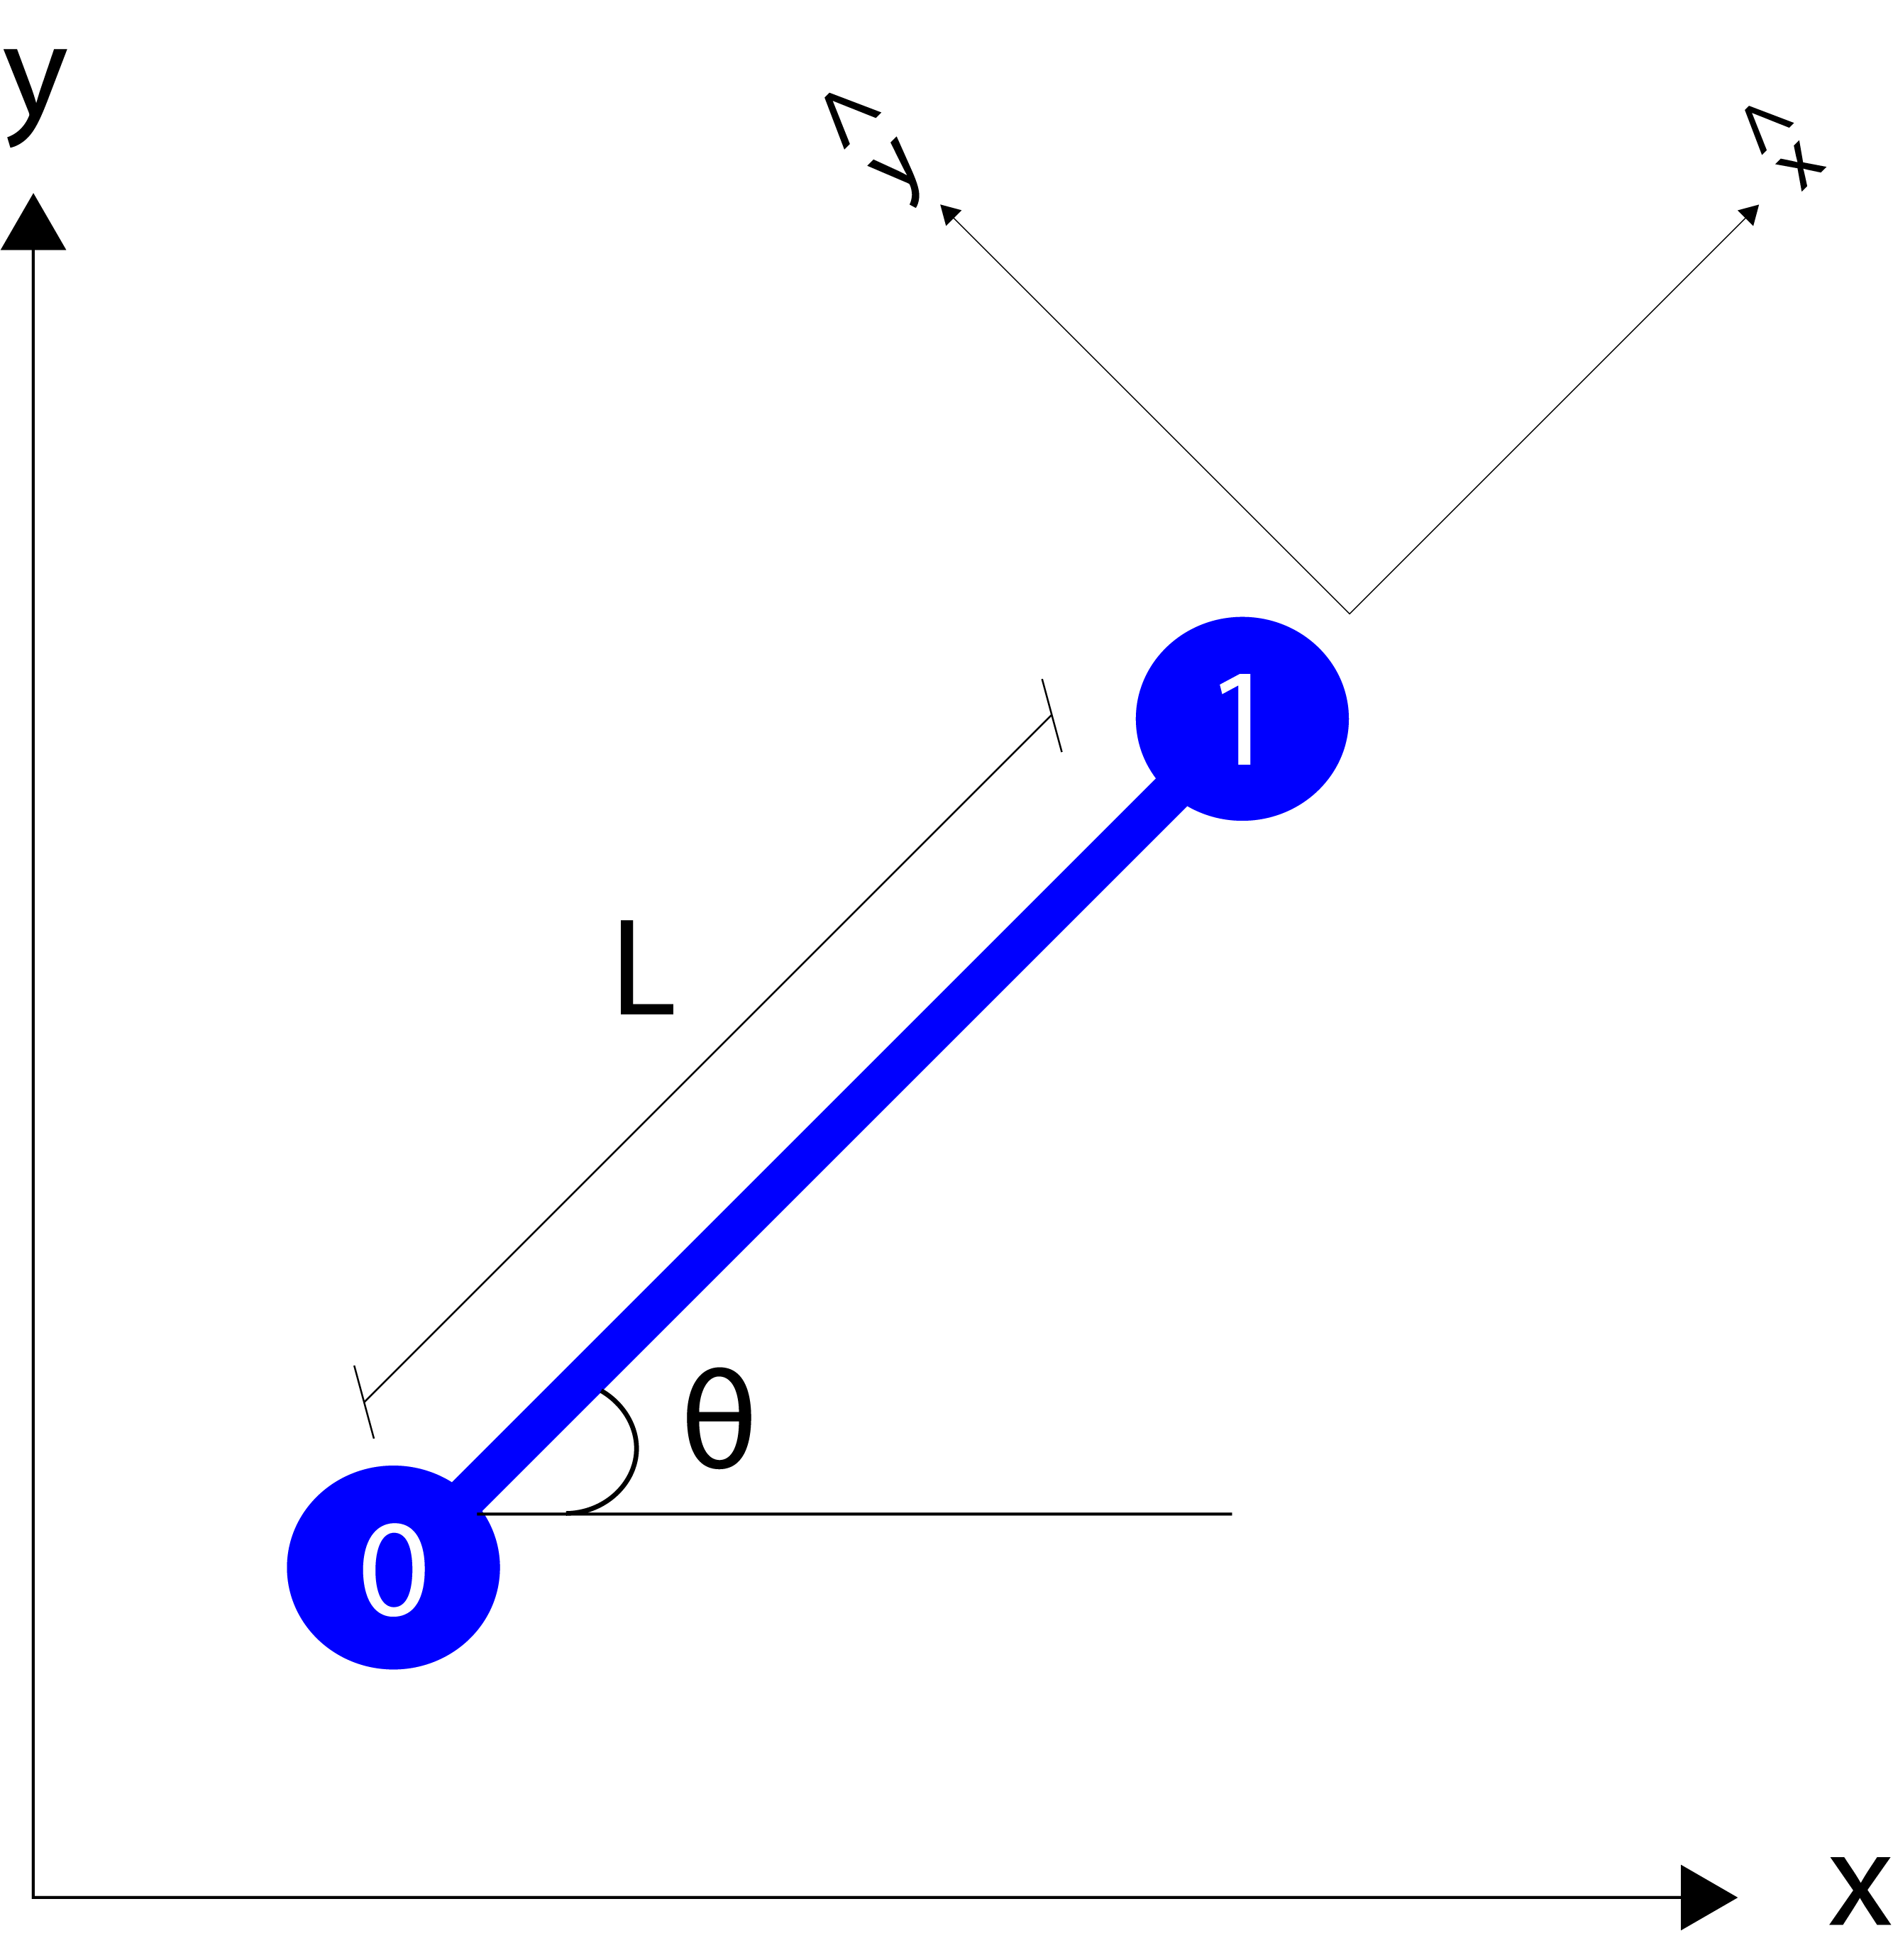

In [22]:
Image(filename = './Chap3_Figures/barre_rotated.png',  width=200, height=200)

On définit les symboles correspondant à l'angle $\theta$ et à la longueur $L$ de la barre. 

In [23]:
theta = Symbol(r'\theta', real=True)

L = Symbol('L', real=True, positive=True)

- Écriver la matrice de connectivité associée à l'exemple
- Exprimer la matrice de positions à partir des variables L et theta

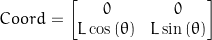

In [24]:
positions = Matrix([
    [0, 0],
    [L*cos(theta), L*sin(theta)]
])

plot_matrix(positions, 'Coord')

conn = np.array([
    [0, 1]
])

plot_matrix(conn, 'C')

#### Matrice de rotation

- La fonction _calculerMatriceRotation_ permet de calculer le bloc matrice r en entrant comme paramètre la position du nœud 0 (p0), et la position du nœud 1 (p1). Elle retourne également la longueur L de la barre. 


- On spécifie que la variable r est une matrice à l'aide de Matrix(r)


- La fonction _simplify_ permet de simplifier l'écriture d'une matrice. 


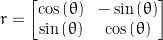

In [25]:
p0 = positions[0, :]
p1 = positions[1, :]

r, _L = calculerMatriceRotation(p0, p1)
r = simplify(Matrix(r))
plot_matrix(r, 'r')

- La matrice de rotation R est définie par $R = \begin{bmatrix} r & 0 \\ 0 & r \end{bmatrix}$.

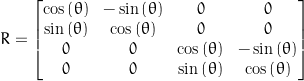

In [26]:
R = zeros(4, 4)
R[0:2, 0:2] = r
R[2:4, 2:4] = r

plot_matrix(R, 'R')

#### Matrice de raideur

- Définisser le module d'elasticité E et l'aire A de la barre de la même manière que nous l'avons fait pour la longueur L. Faites attention à préciser le type de variable considérée (réelle, positive, etc.)

In [27]:
E = Symbol('E', real=True, positive=True)
A = Symbol('A', real=True, positive=True)

- La fonction _calculerMatriceRigiditeLocale_ calcule la matrice de rigidité locale en prenant comme paramètre la rigidité de la barre k. Calculer k.

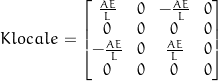

In [28]:
k = E*A/L

Klocale = calculerMatriceRigiditeLocale(k)
Klocale = Matrix(Klocale)

Klocale = simplify(Klocale)
plot_matrix(Klocale, 'Klocale')

- Pour rappel, la matrice de rigidité dans le repère global s'exprime par : 

$$ K = R K^{locale} R^T $$

D'où :

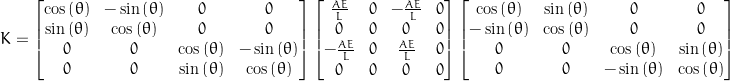

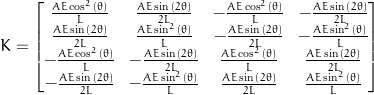

In [29]:
plot_matrix_product(R, Klocale, R.T, 'K')
plot_matrix(simplify(R@Klocale@R.T), 'K')

- La fonction _assemblerMatriceRigidite_ permet d'assembler la matrice de rigidité. Elle prend en entrée la positions des nœuds, la matrice de connectivité et le produit E*A Dans la cas d'une seule barre, la matrice assemblée correspond à la matrice de rigidité K.

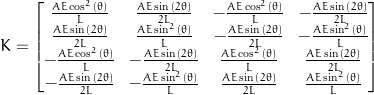

In [30]:
K = assemblerMatriceRigidite(positions, conn, [E*A])
K = simplify(Matrix(K))
plot_matrix(K, 'K')

#### Question :
Dans les cas particuliers de $\theta = 90^\circ$ et $\theta = 180^\circ$, comparer la matrice de raideur K avec la matrice de raideur locale d'une barre

_Indications_ : 
- pour définir des valeurs numériques aux variables, il vous suffit de créer une variable "values" telle que _values = { L : 1, theta : pi/4}_ si on souhaite définir la longueur à 1 m et l'angle de la barre à $\pi$/4


- Pour affecter une valeur à une variable, il suffit d'écrire _variable.subs(values)_. Par exemple, si on souhaite connaître la variable des positions, on écrit _positions.subs(values)_


- Pour répondre à cette question, il vous faudra aussi définir E et A.

#### Réponse :

_Saisir votre réponse ici_

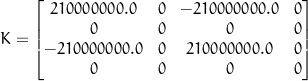

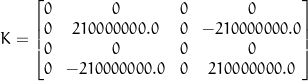

In [31]:
values = {L:1, theta:pi, A:1, E:210e6}
K.subs(values)
plot_matrix(K.subs(values), 'K')

values = {L:1, theta:pi/2, A:1, E:210e6}
K.subs(values)
plot_matrix(K.subs(values), 'K')

### 3.2. Treillis

Nous nous intéressons maintenant au cas des treillis, c'est-à-dire à des structures composées de plusieurs barres. 
- Definisser la positions de 4 nœuds selon votre choix 
- Définisser la matrice de connectivité selon votre choix
- Représenter graphiquement la structure avec la fonction _plot_structure_

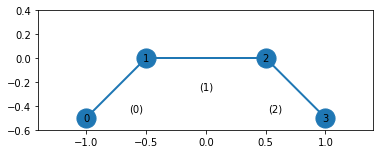

In [32]:
positions = np.array([
    [-1., -.5],
    [-.5, 0],
    [.5, 0],
    [1., -.5]
])

conn = np.array([
    [0, 1],
    [1, 2],
    [2, 3]
])

E = 210e6
A = 1 

plot_structure(positions, conn)

- La fonction _plot_bloc_stiffness_ permet de representer barre après barre l'assemblage de la matrice de raideur. Sur le profil de la matrice K, seules les composantes non nulles apparaissent. 

#### Question:

- Pourquoi n'observons-nous pas un bloc en entier pour la barre 1 (en vert) ?

#### Réponse :

_Saisir votre réponse ici_

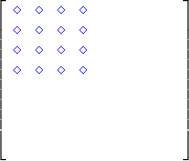

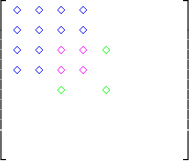

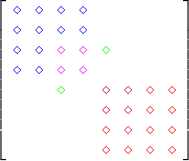

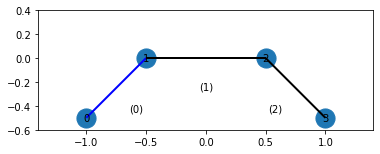

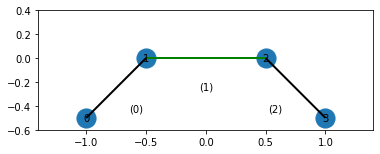

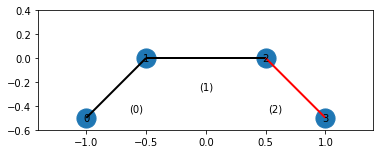

In [33]:
plot_bloc_stiffness(positions, conn, E, A, nb_barre=3)

- Rajouter une barre entre deux nœuds qui ne sont pas déjà reliés, en changeant la matrice de connectivité. 

- Expliquer ma nouvelle forme de la matrice de raideur en changeant la variable _nb_barre_ par 4 dans la fonction _plot_bloc_stiffness_.

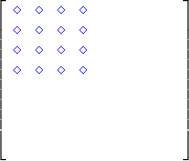

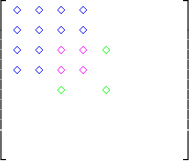

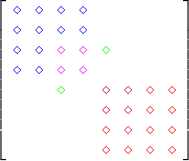

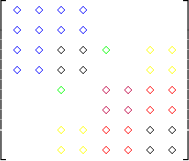

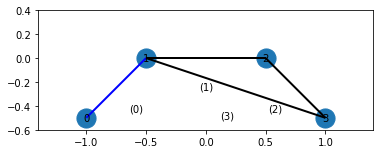

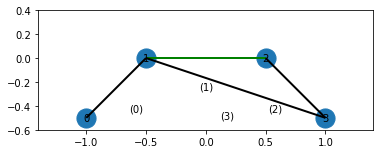

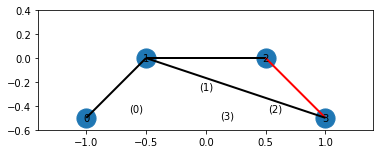

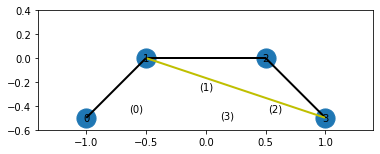

In [34]:
conn = np.array([
    [0, 1],
    [1, 2],
    [2, 3],
    [1, 3]
])

plot_bloc_stiffness(positions, conn, E, A, nb_barre=4)

## 4. Un exemple complet

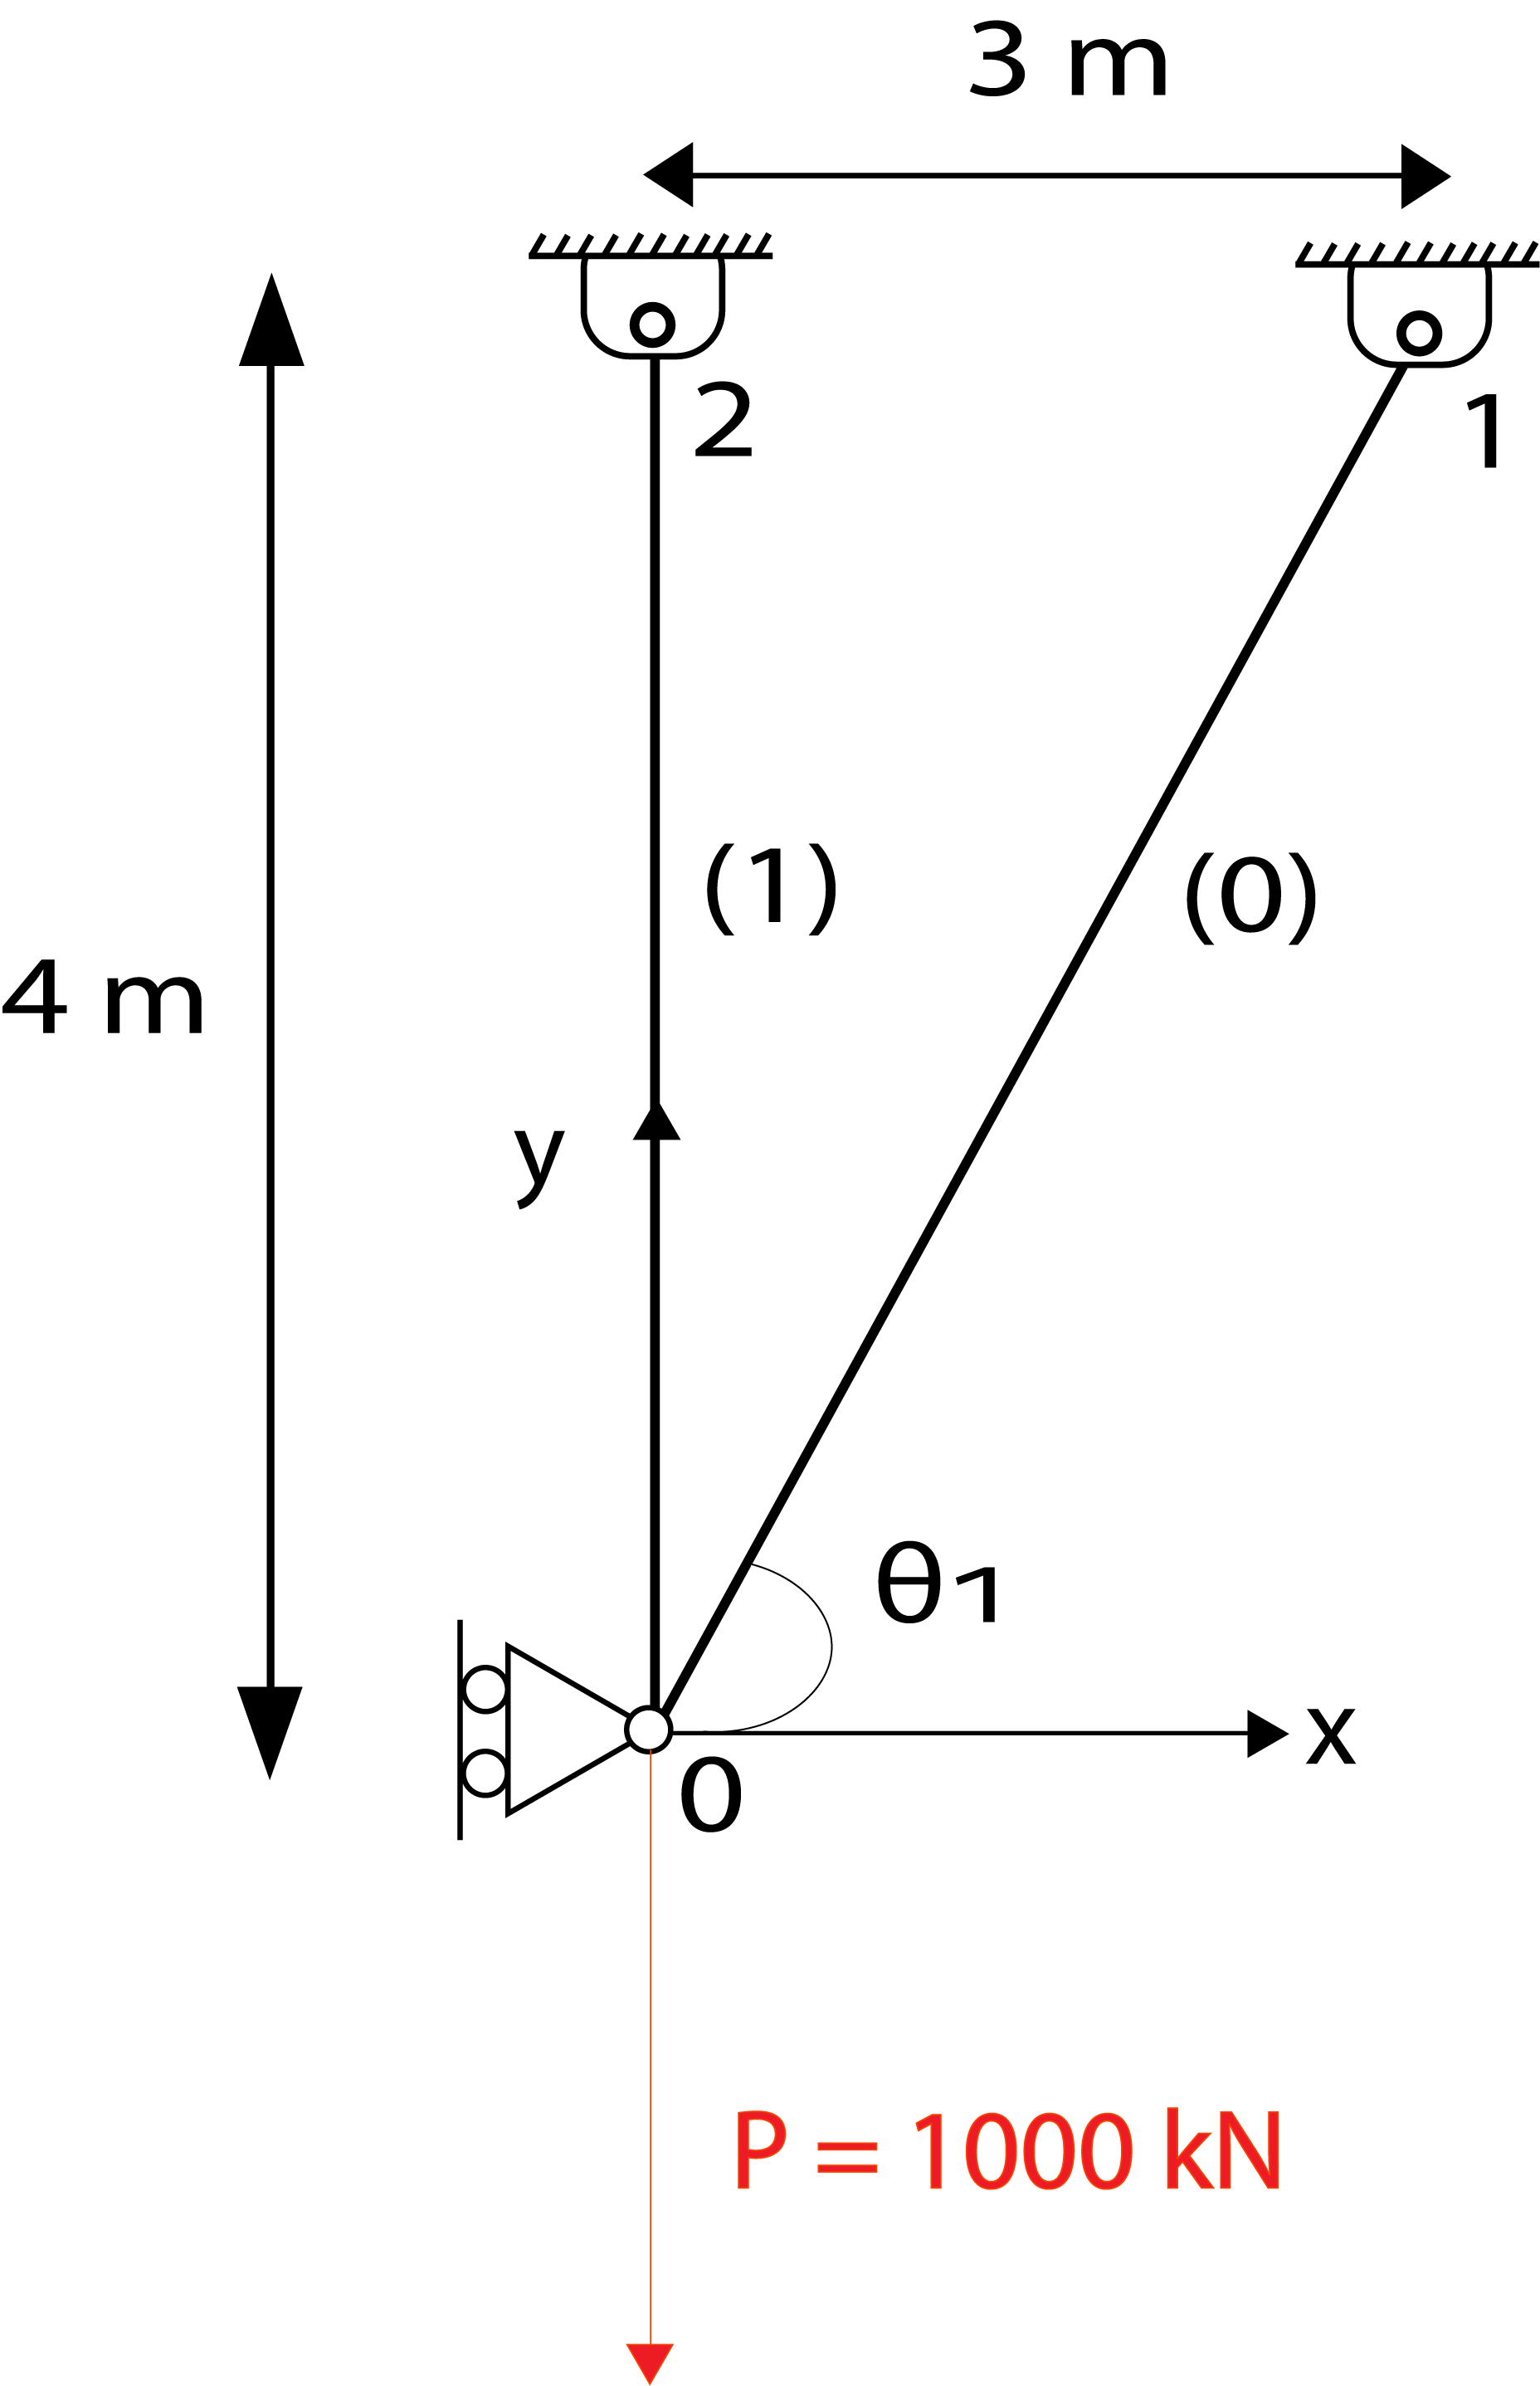

In [56]:
Image(filename = './Chap3_Figures/exemple.png',  width=200, height=200)

### Données

- Aire de la barre 1 : $A_1 = 6.4*10^{-4}$ m$^2$
- Aire de la barre 2 : $A_2 = 6.4*10^{-4}$ m$^2$
- Module d'élasticité des barres 1 et 2 : $E = 210*10^6$ [kN/m$^2$]
- Force au nœud 1 : $P$ = 1000 [kN] (direction -$y$)

### Objectif 

On souhaite connaître le déplacement de chacun des nœuds ainsi que les forces agissant sur ces nœuds dans la direction x et y. Dans ce but, nous détaillerons les étapes de résolution. 

### 1. Définition des variables du problème

Expliciter :
- La matrice de position des nœuds ;
- La matrice de connectivité du problème.

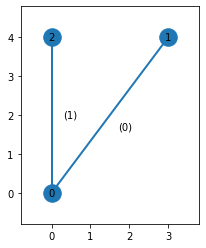

In [2]:
positions = np.array([
    [0, 0],
    [3, 4],
    [0, 4]
])

conn = np.array([
    [0, 1],
    [0, 2]
])

plot_structure(positions, conn)

### 2. Calcul de la matrice de raideur d'une barre

- Définisser l'angle $\theta_1$ et la longeur $L_1$ de la barre 1 connaissant les positions des nœuds.

- Définisser l'angle $\theta_2$ et la longeur $L_2$ de la barre 1 connaissant les positions des nœuds.

- Exprimer la rigidité $k_1$ et $k_2$ des barres 1 et 2 respectivement, à partir des propriétés de la barre. 


- Définisser le vecteur de rigidité $k_{vec}$ = [$k_1$, $k_2$, etc] contenant les rigidités des barres.

- Écrire une fonction calculant la matrice de raideur locale $K_{l}$ d'une barre, en prenant comme entrée la rigidité de la barre $k$. Expliciter cette matrice pour les barres 1 et 2.

In [ ]:
def CalculerMatriceRigiditeLocale(k):
    #
    # Implementez votre code ici
    #
    return Kl

- Écrire une fonction permettant de calculer la matrice de rotation R, connaissant l'angle $\theta$ de la barre par rapport à l'axe x. Pour rappel: 
$$ R = \begin{bmatrix} r & 0 \\ 0 & r \end{bmatrix} $$
où :
\begin{equation}
    \begin{split}
    r = & 
    \begin{bmatrix} 
            \cos{\theta_1}^2 & \cos{\theta_1}\sin{\theta_1} \\
            \cos{\theta_1}\sin{\theta_1} & \sin{\theta_1}^2 
   \end{bmatrix}  
   & = 
   \begin{bmatrix} 
            C_1^2 & C_1 S_1 \\
            C_1 S_1 & S_1^2 
   \end{bmatrix} 
   \end{split}
\end{equation}


- Vérifier que votre fonction est correcte en l'appliquant pour la barre 1 et 2.

In [ ]:
def CalculerMatriceRotation(theta):
    #
    # Implementez votre code ici
    #
    return R

R1 = CalculerMatriceRotation(theta1)
plot_matrix(R1, 'K')

R2 = CalculerMatriceRotation(theta2)
plot_matrix(R2, 'K')

### 3. Assemblage de la matrice de rigidité

- Écrire une fonction permettant d'assembler les matrices de rigidités locales dans la matrice de connectivité connaissant la rigidité des barres (k_vec), le nombre d'élément (nb_elem), le nombre de degrés de liberté (nb_ddl) et la matrice de connectivité (conn).

In [ ]:
# entrer nb_elem et nb_ddl pour ce problème
nb_elem = 2
nb_ddl = 6


def AssemblerMatriceRigidite(k_vec, nb_elem, nb_ddl, conn):
    K = np.zeros((nb_ddl, nb_ddl))
    for e in range(nb_elem):
        #
        # Implementer votre code ici
        # 
    return K

K = AssemblerMatriceRigidite(k_vec, nb_elem, nb_ddl, conn)

plot_matrix(K, 'K')

- Vérifier que la position de vos zéros est cohérente avec les ddl

### 4. Conditions aux limites et calcul des réactions

- Définir les conditions aux limites (6 conditions) 


- Calculer le déplacement de la composante restante (non nulle)


- Calculer les réactions $\lbrace f \rbrace$ grâce à la formule $\lbrace f \rbrace$ = $[K] \lbrace d \rbrace$

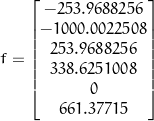

In [52]:
d = np.array([
    [0],
    [-0.0209961],
    [0],
    [0],
    [0],
    [0]
])

f = K*d
plot_matrix(f, 'f')